small_1tung01.jpg


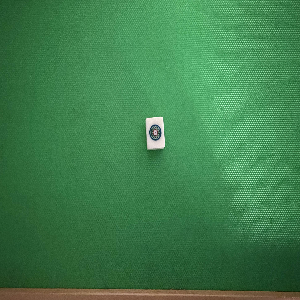

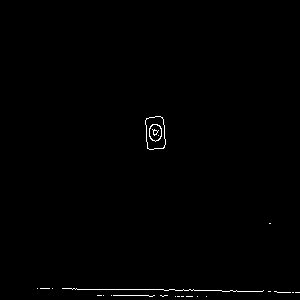

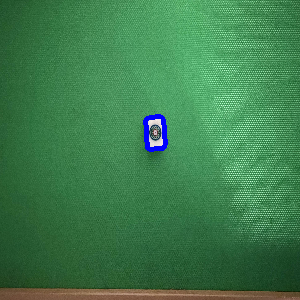

頂點數量: 4
(4, 1, 2)
area: 561.5
向左傾斜（右上抬高）
WL 15.524174696260024 29.274562336608895


small_1tung02.jpg


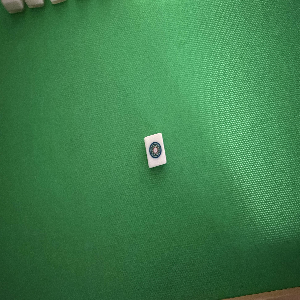

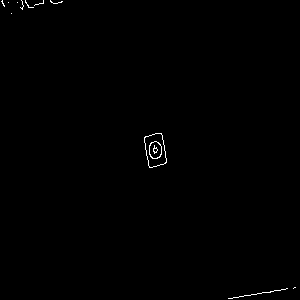

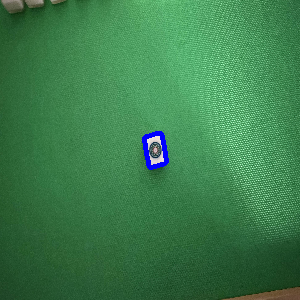

頂點數量: 4
(4, 1, 2)
area: 568.5
向左傾斜（右上抬高）
WL 17.46424919657298 30.4138126514911


small_1tung03.jpg


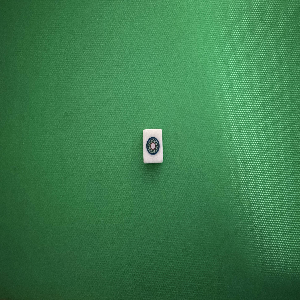

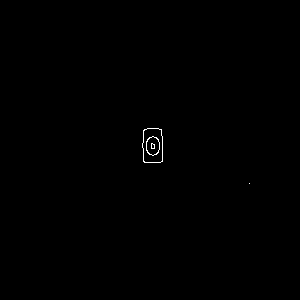

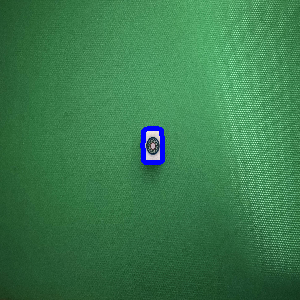

頂點數量: 4
(4, 1, 2)
area: 635.0
向右傾斜（左上抬高）
WL 36.71511950137164 32.01562118716424
fuck
更正：向左傾斜（右上抬高）
right_down_corner = left_down_corner
打橫兩個錯 --> y value 太接近


small_1tung04.jpg


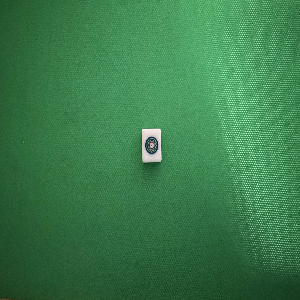

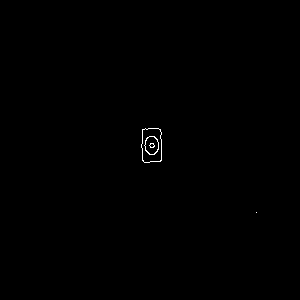

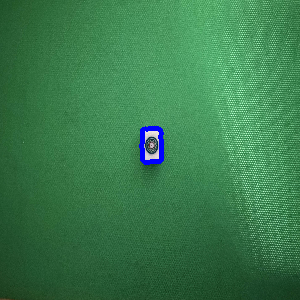

頂點數量: 4
(4, 1, 2)
area: 622.5
向右傾斜（左上抬高）
WL 18.0 0.0
fuck
更正：向左傾斜（右上抬高）
right_up_corner = left_up_corner
打橫兩個錯 --> y value 太接近


small_1tung05.jpg


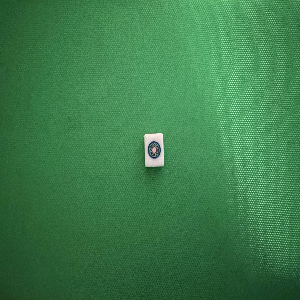

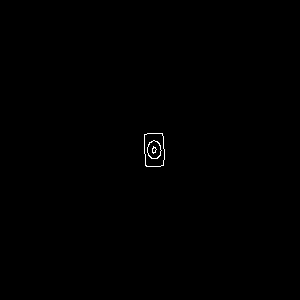

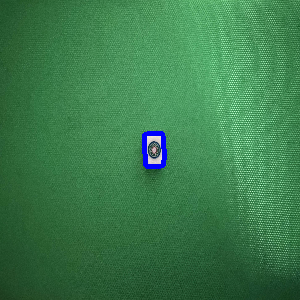

頂點數量: 4
(4, 1, 2)
area: 617.5
向左傾斜（右上抬高）
WL 18.027756377319946 36.359317925395686
right_down_corner = left_down_corner
打橫兩個錯 --> y value 太接近


small_1tung06.jpg


In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler #for 特徵縮放
from sklearn.svm import SVC #非線性
def read_image(file_name):
  img = cv2.imread(file_name)
  img = cv2.resize(img,(300,300))
  img2 = img.copy() #建立一個copy 去畫野上去
  if img is None:
    print("請上傳圖片或指定正確路徑")
  #cv2_imshow(img)
  return(img,img2)
def Pre_process(img): #灰階轉換+blur+canny
  gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)#灰階轉換
  blur_img = cv2.GaussianBlur(gray_img,(5,5),0)#blur
  # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) # 步驟2：CLAHE 局部對比增強（非常有效處理光影不均）
  # clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(16,16)) # 改成這樣（明顯減弱）
  # enhanced = clahe.apply(blur_img)  # 步驟3：可選 - 再做一次輕微模糊或中值濾波
  # enhanced = cv2.medianBlur(enhanced, 3)
  # # 現在用 enhanced 去做 Canny
  # canny = cv2.Canny(enhanced, 100,120)   # 調整這兩個閾值很重要.
  canny = cv2.Canny(blur_img,100,100) #邊緣化
  # kernel = np.ones((3,3),np.uint8)
  # canny = cv2.dilate(canny,kernel,iterations =1)
  #cv2_imshow(canny)
  return(canny)
def detect_contour(canny,img2):
  vertices = np.ones([4,2])
  area_max = 0
  contours, hierarchy = cv2.findContours(canny,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)
  for cnt in contours:
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt,True)
    if (area > 200) and  (area > area_max):
      area_max = area
      cv2.drawContours(img2,cnt,-1,(255,0,0),4)
      cv2_imshow(img2)
      peri = cv2.arcLength(cnt,True)
      vertices = cv2.approxPolyDP(cnt,peri*0.09,True)
      #print(vertices)
      print("頂點數量:", len(vertices))
    if len(vertices) == 4 :
      vertices_4_corners = vertices

  print(vertices_4_corners.shape)

  print("area:",area_max )
  # prevent the case that the outer contour is not closed
  # if (area_max <4500) and len (vertices) == 4:
  #     print("the outer contour is not closed")
  #     kernel = np.ones((3,3),np.uint8)
  #     canny = cv2.dilate(canny,kernel,iterations =1)
  #     contours, hierarchy = cv2.findContours(canny,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)
  #     for cnt in contours:
  #       area = cv2.contourArea(cnt)
  #       peri = cv2.arcLength(cnt,True)
  #       if (area > 2000) and  (area > area_max):
  #         area_max = area
  #         cv2.drawContours(img2,cnt,-1,(255,0,0),4)
  #         cv2_imshow(img2)
  #         peri = cv2.arcLength(cnt,True)
  #         vertices = cv2.approxPolyDP(cnt,peri*0.09,True)
  #         #print(vertices)
  #         print("頂點數量:", len(vertices))
  #         print("area:",area )



  return (vertices_4_corners)
def sort_order(vertices):
  vertices_orderx =  np.empty([4,2])
  vertices_ordery =  np.empty([4,2])
  for i in range(4):
    vertices_orderx [i,0] = vertices[i,0,0]
    vertices_orderx [i,1] = vertices[i,0,1]
    vertices_ordery [i,0] = vertices[i,0,0]
    vertices_ordery [i,1] = vertices[i,0,1]
  vertices_orderx = vertices_orderx[np.argsort(vertices_orderx[:, 0])]
  vertices_ordery = vertices_ordery[np.argsort(vertices_ordery[:, 1])]

  return vertices_orderx,vertices_ordery
def find_four_corners(vertices,vertices_orderx,vertices_ordery):
  right_up_corner = np.empty([2])
  left_up_corner = np.empty([2])
  right_down_corner = np.empty([2])
  left_down_corner = np.empty([2])
  R_or_L = 'r'
  # 計算四個點的平均 x（中心 x）
  center_x = np.mean(vertices[:, 0, 0])
  # 找到最高點（y 最小的點）的 x
  highest_idx = np.argmin(vertices[:, 0, 1])
  highest_x = vertices[highest_idx, 0, 0]
  if highest_x <  center_x:
    print("向右傾斜（左上抬高）")
    R_or_L = 'r'
    right_down_corner[0] = vertices_ordery[3,0]    #最低 = 右下
    right_down_corner[1] = vertices_ordery[3,1]
    left_down_corner[0] = vertices_orderx[0,0]   # 最左的data ＝左下
    left_down_corner[1] = vertices_orderx[0,1]
    right_up_corner[0] = vertices_orderx[3,0]   #最右的data ＝右上
    right_up_corner[1] = vertices_orderx[3,1]
    left_up_corner[0] = vertices_ordery[0,0] #最高的data ＝左上
    left_up_corner[1] = vertices_ordery[0,1]
  else:
      print("向左傾斜（右上抬高）")
      R_or_L = 'l'
      right_down_corner[0] = vertices_orderx[3,0] #右下 --> 最右 (最大x)
      right_down_corner[1] = vertices_orderx[3,1]
      left_down_corner[0] = vertices_ordery[3,0] # 左下 --> 最下 (最大y)
      left_down_corner[1] = vertices_ordery[3,1]
      right_up_corner[0] = vertices_ordery[0,0] #最高的data ＝右上
      right_up_corner[1] = vertices_ordery[0,1]
      left_up_corner[0] = vertices_orderx[0,0] #最左= 左上
      left_up_corner[1] = vertices_orderx[0,1]
  width = math.sqrt(((left_up_corner[1] - right_up_corner[1])**2) + ((left_up_corner[0] - right_up_corner[0])**2))
  length = math.sqrt(((left_down_corner[1] - left_up_corner[1])**2) + ((left_down_corner[0] - left_up_corner[0])**2))
  print("WL",width,length)
  if width > length:
    print('fuck')
    if R_or_L == 'r':
      print("更正：向左傾斜（右上抬高）")
      right_down_corner[0] = vertices_orderx[3,0] #右下 --> 最右 (最大x)
      right_down_corner[1] = vertices_orderx[3,1]
      left_down_corner[0] = vertices_ordery[3,0] # 左下 --> 最下 (最大y)
      left_down_corner[1] = vertices_ordery[3,1]
      right_up_corner[0] = vertices_ordery[0,0] #最高的data ＝右上
      right_up_corner[1] = vertices_ordery[0,1]
      left_up_corner[0] = vertices_orderx[0,0] #最左= 左上
      left_up_corner[1] = vertices_orderx[0,1]
      R_or_L = "l"
    else:
      print("更正： 向右傾斜（左上抬高）")
      right_down_corner[0] = vertices_ordery[3,0]    #最低 = 右下
      right_down_corner[1] = vertices_ordery[3,1]
      left_down_corner[0] = vertices_orderx[0,0]   # 最左的data ＝左下
      left_down_corner[1] = vertices_orderx[0,1]
      right_up_corner[0] = vertices_orderx[3,0]   #最右的data ＝右上
      right_up_corner[1] = vertices_orderx[3,1]
      left_up_corner[0] = vertices_ordery[0,0] #最高的data ＝左上
      left_up_corner[1] = vertices_ordery[0,1]
      R_or_L = "r"




  return right_up_corner ,left_up_corner , right_down_corner , left_down_corner,R_or_L
def check_error(right_up_corner ,left_up_corner , right_down_corner , left_down_corner,R_or_L,vertices_orderx,vertices_ordery):
  error_LR = False #打橫兩個錯 --> y value 太接近
  error_UD = False #打直兩個錯 --> x value 太接近
  if np.array_equal(right_up_corner, left_up_corner):
      print("right_up_corner = left_up_corner")
      error_LR = True
  elif np.array_equal(right_up_corner, right_down_corner):
      print("right_up_corner = right_down_corner")
      error_UD = True
  elif np.array_equal(left_up_corner, left_down_corner):
      print("left_up_corner = left_down_corner")
      error_UD = True
  elif np.array_equal(right_down_corner, left_down_corner):
      print("right_down_corner = left_down_corner")
      error_LR = True
  if error_LR == True:
      print("打橫兩個錯 --> y value 太接近")
      # 分左右
      if vertices_orderx[0,1] > vertices_orderx[1,1]: #最左既Y  >  第二左Y （左） 向右傾斜
        left_up_corner = vertices_orderx [1,:]   #第二左Y -->左上
        left_down_corner = vertices_orderx[0,:] #最左既Y  -->左下
      else :                                     #最左既Y  ＜ 第二左Y  向左傾斜
       left_up_corner = vertices_orderx [0,:]  #最左Y -->左上
       left_down_corner = vertices_orderx[1,:] #第二左Y -->左下
      if vertices_orderx[2,1] > vertices_orderx[3,1]: #第三左既Y  >  第四左Y  （右） 向右傾斜
        right_up_corner = vertices_orderx[3,:] #第四左Y --> 右下
        right_down_corner = vertices_orderx[2,:] #第三左既Y --＞右下
      else:                                   #第三左既Y  <  第四左Y     向左傾斜
        right_up_corner = vertices_orderx[2,:] #第三左Y --> 右上
        right_down_corner = vertices_orderx[3,:] #第四左Y --> 右下
  elif error_UD == True:
      # 分上下
      print("打直兩個錯 --> x value 太接近")
      if vertices_ordery[0,0] > vertices_ordery[1,0]: #最高x > 第二高x    （上） 向左傾斜
        left_up_corner = vertices_ordery [1,:]   #第二高x -->左上
        right_up_corner = vertices_ordery[0,:] #最高x --> 右上
      else :                                    #最高x < 第二高x  向右傾斜
       right_up_corner = vertices_ordery [1,:] #第二高x -->右上
       left_up_corner = vertices_ordery[0,:] #最高x --> 左上
      if vertices_ordery[2,0] > vertices_ordery[3,0]: # 第三高x > 第四高x（下）向左傾斜
        right_down_corner = vertices_ordery[2,:] # 第三高 --> 右下
        left_down_corner = vertices_ordery[3,:] # 第四高 --> 左下
      else:                                       # 第三高x < 第四高x（下） 向右傾斜
        right_down_corner = vertices_ordery[3,:] # 第四高 --> 右下
        left_down_corner = vertices_ordery[2,:] # 第三高 --> 左下

  return right_up_corner ,left_up_corner , right_down_corner , left_down_corner

def crop (right_up_corner ,left_up_corner , right_down_corner , left_down_corner,img):
  src_pts = np.array([left_up_corner, #左上
                      right_up_corner, #右上
                      left_down_corner, #左下
                      right_down_corner], #右下
                      dtype=np.float32)
  width = math.sqrt(((src_pts[0,1] - src_pts[1,1])**2) + ((src_pts[0,0] - src_pts[1,0])**2))
  length = math.sqrt(((src_pts[2,1] - src_pts[0,1])**2) + ((src_pts[2,0] - src_pts[0,0])**2))


  dst_pts = np.array([[0,0], #左上
                      [width, 0], #右上
                      [0, length], #左下
                      [width, length]], #右下
                      dtype=np.float32)

  M = cv2.getPerspectiveTransform(src_pts, dst_pts)
  result = cv2.warpPerspective(img, M, (int(width),int(length)))
  cv2_imshow(result)
  return result
# 在主迴圈裡，crop_image = crop(...) 之後加這段

# 去黑邊函數
def remove_black_border(no_black):
    gray = cv2.cvtColor(no_black, cv2.COLOR_BGR2GRAY)
    # 用低閾值二值化，抓出非黑區域
    _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
    # 找非零像素
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        # 加一點 padding 避免切太緊
        padding = 5
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(w + 2*padding, no_black.shape[1] - x)
        h = min(h + 2*padding, no_black.shape[0] - y)
        return no_black[y:y+h, x:x+w]
    return no_black

def HOG (result):
  result = cv2.resize(result,(20,30))
  image_gray = cv2.cvtColor(result,cv2.COLOR_BGR2GRAY)
  # Compute HOG + visualization
  fd, hog_image = hog(
      image_gray,
      orientations=9,              # number of orientation bins (classic = 9)
      pixels_per_cell=(8, 8),      # cell size (classic = 8×8 pixels)
      cells_per_block=(2, 2),      # block size (classic = 2×2 cells → 4 cells/block)
      block_norm='L2-Hys',         # most common & robust normalization
      visualize=True,              # return visualization image
      transform_sqrt=False,        # optional gamma compression (usually False)
      feature_vector=True)          # return flattened vector (default)
  return fd, hog_image,image_gray
def display_hog_result(image_gray,hog_image):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
  ax1.axis('off')
  ax1.imshow(image_gray, cmap=plt.cm.gray)
  ax1.set_title('Input Grayscale Image')
  # Optional: rescale hog_image for better visibility (sometimes very dark)
  hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
  ax2.axis('off')
  ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
  ax2.set_title('HOG Visualization\n(oriented gradients)')
  plt.tight_layout()
  plt.show()

def get_features(file_name):
  img,img2 = read_image(file_name)
  canny = Pre_process(img)
  vertices = detect_contour(canny,img2)
  vertices_orderx,vertices_ordery = sort_order(vertices)
  right_up_corner ,left_up_corner , right_down_corner , left_down_corner ,R_or_L= find_four_corners(vertices,vertices_orderx,vertices_ordery)
  right_up_corner ,left_up_corner , right_down_corner , left_down_corner = check_error(right_up_corner ,left_up_corner , right_down_corner , left_down_corner,R_or_L,vertices_orderx,vertices_ordery)
  crop_image = crop (right_up_corner ,left_up_corner , right_down_corner , left_down_corner,img)
  no_black = remove_black_border(crop_image)
  fd, hog_image ,image_gray = HOG (no_black)
  #display_hog_result(image_gray,hog_image)
  return fd
one_tung_name = ["small_1tung01.jpg", "small_1tung02.jpg", "small_1tung03.jpg", "small_1tung04.jpg", "small_1tung05.jpg", "small_1tung06.jpg",   "small_1tung09.jpg", "small_1tung10.jpg", "small_1tung11.jpg"]
two_tung_name =["small_2tung01.jpg","small_2tung02.jpg","small_2tung04.jpg","small_2tung05.jpg","small_2tung06.jpg","small_2tung07.jpg","small_2tung08.jpg","small_2tung09.jpg","small_2tung10.jpg","small_2tung11.jpg","small_2tung13.jpg","small_2tung14.jpg","small_2tung15.jpg","small_2tung16.jpg","small_2tung17.jpg","small_2tung18.jpg","small_2tung20.jpg","small_2tung21.jpg","small_2tung22.jpg","small_2tung23.jpg","small_2tung24.jpg"]

three_tung_name = ["small_3tung01.jpg","small_3tung03.jpg","small_3tung04.jpg","small_3tung05.jpg","small_3tung06.jpg","small_3tung07.jpg","small_3tung09.jpg","small_3tung12.jpg","small_3tung13.jpg","small_3tung14.jpg","small_3tung15.jpg","small_3tung16.jpg","small_3tung17.jpg","small_3tung18.jpg","small_3tung19.jpg","small_3tung20.jpg","small_3tung21.jpg","small_3tung22.jpg","small_3tung23.jpg","small_3tung24.jpg","small_3tung25.jpg","small_3tung26.jpg","small_3tung28.jpg","small_3tung29.jpg","small_3tung30.jpg"]
four_tung_name = ["small_4tung01.jpg","small_4tung02.jpg","small_4tung03.jpg","small_4tung04.jpg","small_4tung05.jpg","small_4tung06.jpg","small_4tung07.jpg","small_4tung08.jpg","small_4tung09.jpg","small_4tung10.jpg","small_4tung11.jpg","small_4tung12.jpg","small_4tung13.jpg","small_4tung14.jpg","small_4tung15.jpg","small_4tung17.jpg","small_4tung18.jpg","small_4tung19.jpg","small_4tung20.jpg"]
five_tung_name = ["small_5tung01.jpg","small_5tung02.jpg","small_5tung03.jpg","small_5tung04.jpg","small_5tung05.jpg","small_5tung06.jpg","small_5tung07.jpg","small_5tung09.jpg","small_5tung10.jpg","small_5tung11.jpg","small_5tung12.jpg","small_5tung13.jpg","small_5tung14.jpg","small_5tung16.jpg","small_5tung17.jpg","small_5tung18.jpg","small_5tung19.jpg","small_5tung20.jpg","small_5tung21.jpg","small_5tung22.jpg","small_5tung23.jpg","small_5tung24.jpg","small_5tung25.jpg","small_5tung26.jpg"]
six_tung_name = ["small_6tung01.jpg","small_6tung03.jpg","small_6tung04.jpg","small_6tung05.jpg","small_6tung06.jpg","small_6tung08.jpg","small_6tung09.jpg","small_6tung10.jpg","small_6tung12.jpg","small_6tung14.jpg","small_6tung15.jpg","small_6tung16.jpg","small_6tung17.jpg","small_6tung18.jpg","small_6tung19.jpg","small_6tung20.jpg","small_6tung21.jpg","small_6tung22.jpg"]
seven_tung_name = ["small_7tung01.jpg","small_7tung02.jpg","small_7tung03.jpg","small_7tung04.jpg","small_7tung05.jpg","small_7tung06.jpg","small_7tung07.jpg","small_7tung09.jpg","small_7tung11.jpg","small_7tung12.jpg","small_7tung13.jpg","small_7tung14.jpg","small_7tung16.jpg","small_7tung18.jpg","small_7tung19.jpg","small_7tung20.jpg","small_7tung23.jpg","small_7tung25.jpg","small_7tung26.jpg"]
eight_tung_name =["small_8tung01.jpg","small_8tung02.jpg","small_8tung03.jpg","small_8tung04.jpg","small_8tung05.jpg","small_8tung06.jpg","small_8tung07.jpg","small_8tung08.jpg","small_8tung09.jpg","small_8tung10.jpg","small_8tung11.jpg","small_8tung12.jpg","small_8tung13.jpg","small_8tung14.jpg","small_8tung15.jpg","small_8tung16.jpg","small_8tung17.jpg","small_8tung18.jpg","small_8tung19.jpg","small_8tung21.jpg","small_8tung22.jpg"]
nine_tung_name = ["small_9tung01.jpg","small_9tung03.jpg","small_9tung04.jpg","small_9tung05.jpg","small_9tung07.jpg","small_9tung08.jpg","small_9tung10.jpg","small_9tung11.jpg",]
one_mang_names = [
    "1mang001.jpg","1mang002.jpg" , "1mang003.jpg", "1mang004.jpg", "1mang005.jpg",
    "1mang006.jpg", "1mang007.jpg", "1mang008.jpg", "1mang009.jpg", "1mang010.jpg",
    "1mang011.jpg", "1mang012.jpg",  "1mang014.jpg", "1mang015.jpg",
    "1mang016.jpg", "1mang017.jpg", "1mang018.jpg", "1mang019.jpg"
]

two_mang_names = [
    "2mang001.jpg", "2mang002.jpg", "2mang003.jpg", "2mang004.jpg", "2mang005.jpg",
    "2mang006.jpg", "2mang007.jpg", "2mang008.jpg", "2mang009.jpg", "2mang010.jpg",
    "2mang011.jpg", "2mang012.jpg", "2mang013.jpg", "2mang014.jpg", "2mang015.jpg",
    "2mang016.jpg", "2mang017.jpg", "2mang018.jpg", "2mang019.jpg", "2mang020.jpg",
    "2mang021.jpg",  "2mang023.jpg"
]

three_mang_names = [
    "3mang001.jpg", "3mang002.jpg", "3mang003.jpg", "3mang004.jpg", "3mang005.jpg",
    "3mang006.jpg", "3mang007.jpg", "3mang008.jpg", "3mang009.jpg", "3mang010.jpg",
    "3mang011.jpg", "3mang012.jpg", "3mang013.jpg", "3mang014.jpg", "3mang015.jpg",
    "3mang016.jpg", "3mang017.jpg", "3mang018.jpg", "3mang019.jpg", "3mang020.jpg",
    "3mang021.jpg", "3mang022.jpg"
]

four_mang_names = [
    "4mang001.jpg", "4mang002.jpg",
    "4mang006.jpg", "4mang007.jpg", "4mang008.jpg",  "4mang010.jpg",
    "4mang011.jpg", "4mang012.jpg", "4mang013.jpg", "4mang014.jpg", "4mang015.jpg",

]

five_mang_names = [
     "5mang001.jpg", "5mang002.jpg","5mang003.jpg", "5mang004.jpg",
     "5mang007.jpg", "5mang008.jpg", "5mang009.jpg", "5mang010.jpg",
    "5mang011.jpg", "5mang012.jpg", "5mang013.jpg", "5mang014.jpg", "5mang015.jpg",
     "5mang017.jpg",  "5mang019.jpg", "5mang020.jpg"
]

six_mang_names = [
    "6mang001.jpg",   "6mang004.jpg", "6mang005.jpg",
    "6mang006.jpg", "6mang007.jpg", "6mang008.jpg", "6mang009.jpg", "6mang010.jpg",
    "6mang011.jpg", "6mang012.jpg", "6mang013.jpg", "6mang014.jpg", "6mang015.jpg",
    "6mang016.jpg", "6mang017.jpg", "6mang018.jpg", "6mang019.jpg", "6mang0209.jpg",
    "6mang021.jpg", "6mang022.jpg"
]

seven_mang_names = [
    "7mang001.jpg", "7mang002.jpg", "7mang003.jpg", "7mang004.jpg", "7mang005.jpg",
    "7mang006.jpg", "7mang007.jpg", "7mang008.jpg", "7mang009.jpg", "7mang010.jpg",
    "7mang011.jpg", "7mang012.jpg", "7mang013.jpg", "7mang014.jpg", "7mang015.jpg",
    "7mang016.jpg"
]

eight_mang_names = [
    "8mang001.jpg", "8mang002.jpg", "8mang003.jpg",  "8mang005.jpg",
     "8mang007.jpg",  "8mang009.jpg", "8mang010.jpg",
    "8mang011.jpg", "8mang012.jpg", "8mang013.jpg", "8mang014.jpg", "8mang015.jpg",
    "8mang016.jpg", "8mang017.jpg", "8mang018.jpg", "8mang019.jpg",
    "8mang021.jpg"
]

nine_mang_names = [
    "9mang001.jpg", "9mang002.jpg", "9mang003.jpg", "9mang004.jpg", "9mang005.jpg",
    "9mang006.jpg", "9mang007.jpg",  "9mang009.jpg", "9mang010.jpg",
    "9mang011.jpg", "9mang012.jpg", "9mang013.jpg", "9mang014.jpg",
     "9mang017.jpg", "9mang018.jpg", "9mang019.jpg",
     "9mang022.jpg"
]
one_suo_names = [
    "1suo001.jpg", "1suo002.jpg", "1suo003.jpg", "1suo004.jpg", "1suo005.jpg",
    "1suo006.jpg", "1suo007.jpg", "1suo008.jpg", "1suo009.jpg", "1suo010.jpg",
    "1suo011.jpg", "1suo012.jpg", "1suo013.jpg", "1suo014.jpg", "1suo015.jpg",
    "1suo016.jpg", "1suo017.jpg", "1suo018.jpg", "1suo019.jpg", "1suo020.jpg"
]

two_suo_names = [
    "2suo001.jpg", "2suo002.jpg",  "2suo004.jpg", "2suo005.jpg",
    "2suo006.jpg", "2suo007.jpg", "2suo008.jpg", "2suo009.jpg", "2suo010.jpg",
    "2suo011.jpg", "2suo012.jpg", "2suo013.jpg", "2suo014.jpg", "2suo015.jpg",
    "2suo016.jpg", "2suo017.jpg", "2suo018.jpg", "2suo019.jpg", "2suo020.jpg"
]

three_suo_names = [
    "3suo001.jpg", "3suo002.jpg", "3suo004.jpg", "3suo005.jpg",
    "3suo006.jpg", "3suo007.jpg",  "3suo010.jpg",
    "3suo011.jpg", "3suo012.jpg", "3suo013.jpg", "3suo014.jpg", "3suo015.jpg",
    "3suo016.jpg", "3suo017.jpg", "3suo018.jpg"
]

four_suo_names = [
    "4suo001.jpg", "4suo002.jpg", "4suo003.jpg", "4suo004.jpg", "4suo005.jpg",
      "4suo008.jpg", "4suo009.jpg", "4suo010.jpg",
    "4suo011.jpg", "4suo012.jpg", "4suo013.jpg",  "4suo015.jpg",
    "4suo016.jpg", "4suo017.jpg", "4suo018.jpg",  "4suo020.jpg"
]

five_suo_names = [
    "5suo001.jpg", "5suo002.jpg", "5suo003.jpg", "5suo004.jpg", "5suo005.jpg",
    "5suo006.jpg", "5suo007.jpg", "5suo008.jpg", "5suo009.jpg", "5suo010.jpg",
    "5suo011.jpg", "5suo012.jpg", "5suo013.jpg", "5suo014.jpg", "5suo015.jpg",
     "5suo017.jpg"
]

six_suo_names = [
    "6suo001.jpg",  "6suo003.jpg", "6suo004.jpg",
     "6suo007.jpg", "6suo008.jpg", "6suo009.jpg", "6suo010.jpg",
      "6suo013.jpg", "6suo014.jpg", "6suo015.jpg",
    "6suo016.jpg", "6suo017.jpg", "6suo018.jpg"
]

seven_suo_names = [
    "7suo001.jpg", "7suo002.jpg", "7suo003.jpg", "7suo004.jpg", "7suo005.jpg",
    "7suo006.jpg", "7suo007.jpg", "7suo008.jpg", "7suo009.jpg", "7suo010.jpg",
    "7suo011.jpg", "7suo012.jpg", "7suo013.jpg", "7suo014.jpg", "7suo015.jpg",
    "7suo016.jpg", "7suo017.jpg", "7suo018.jpg", "7suo019.jpg"]

eight_suo_names = [
    "8suo001.jpg",    "8suo005.jpg",
    "8suo006.jpg", "8suo007.jpg", "8suo008.jpg",  "8suo010.jpg",
      "8suo013.jpg",
     "8suo017.jpg", "8suo018.jpg", "8suo019.jpg",
]

nine_suo_names = [
     "9suo002.jpg",  "9suo004.jpg", "9suo005.jpg",
     "9suo007.jpg", "9suo008.jpg", "9suo009.jpg", "9suo010.jpg",
    "9suo011.jpg", "9suo012.jpg", "9suo013.jpg", "9suo014.jpg",
     "9suo017.jpg", "9suo018.jpg", "9suo019.jpg"]
dong_names = [
    "dong001.jpg", "dong002.jpg", "dong003.jpg", "dong004.jpg", "dong005.jpg",
     "dong008.jpg",
    "dong011.jpg", "dong012.jpg", "dong013.jpg", "dong014.jpg", "dong015.jpg",
    "dong016.jpg", "dong017.jpg", "dong018.jpg", "dong019.jpg", "dong020.jpg"
]

nam_names = [
      "nam003.jpg",
    "nam006.jpg", "nam007.jpg", "nam008.jpg",
    "nam011.jpg",  "nam013.jpg", "nam014.jpg", "nam015.jpg",
    "nam016.jpg",   "nam019.jpg", "nam020.jpg"
]

sike_names = [
    "sike001.jpg", "sike002.jpg", "sike003.jpg", "sike004.jpg", "sike005.jpg",
    "sike006.jpg", "sike007.jpg", "sike008.jpg", "sike009.jpg", "sike010.jpg",
    "sike011.jpg", "sike012.jpg", "sike013.jpg", "sike014.jpg", "sike015.jpg",
    "sike016.jpg", "sike017.jpg", "sike018.jpg", "sike019.jpg", "sike020.jpg"
]

buck_names = [
     "buck002.jpg", "buck003.jpg", "buck004.jpg", "buck005.jpg",
    "buck006.jpg", "buck007.jpg", "buck008.jpg", "buck009.jpg", "buck010.jpg",
    "buck011.jpg", "buck012.jpg", "buck014.jpg", "buck015.jpg",
    "buck016.jpg", "buck017.jpg", "buck018.jpg"
]

chung_names = [
      "chung003.jpg", "chung004.jpg",
    "chung006.jpg",  "chung008.jpg", "chung009.jpg", "chung010.jpg",
    "chung011.jpg",  "chung013.jpg",
      "chung018.jpg", "chung019.jpg"
]

fat_names = [
    "fat001.jpg", "fat002.jpg", "fat003.jpg", "fat004.jpg", "fat005.jpg",
    "fat006.jpg", "fat007.jpg", "fat008.jpg", "fat009.jpg",
      "fat013.jpg", "fat014.jpg", "fat015.jpg",
    "fat016.jpg", "fat017.jpg"
]

white_board_names = [
    "white_board001.jpg", "white_board002.jpg", "white_board003.jpg", "white_board004.jpg", "white_board005.jpg",
    "white_board006.jpg", "white_board007.jpg", "white_board008.jpg", "white_board009.jpg", "white_board010.jpg",
    "white_board011.jpg", "white_board012.jpg", "white_board013.jpg",  "white_board015.jpg",
    "white_board016.jpg", "white_board017.jpg",  ]
import numpy as np

# ==================== 1. 先計算總樣本數 ====================
x_0 = (
    len(one_tung_name) + len(two_tung_name) + len(three_tung_name) + len(four_tung_name) +
    len(five_tung_name) + len(six_tung_name) + len(seven_tung_name) + len(eight_tung_name) + len(nine_tung_name) +
    len(one_mang_names) + len(two_mang_names) + len(three_mang_names) + len(four_mang_names) +
    len(five_mang_names) + len(six_mang_names) + len(seven_mang_names) + len(eight_mang_names) + len(nine_mang_names) +
    len(one_suo_names) + len(two_suo_names) + len(three_suo_names) + len(four_suo_names) +
    len(five_suo_names) + len(six_suo_names) + len(seven_suo_names) + len(eight_suo_names) + len(nine_suo_names) +
    len(dong_names) + len(nam_names) + len(sike_names) + len(buck_names) +
    len(chung_names) + len(fat_names) + len(white_board_names)
)

# ==================== 2. 建立 x 和 y ====================
y = []
x = np.empty((x_0, 72))   # 正確寫法：(rows, cols)

# ==================== 3. 用大列表統一所有牌型 ====================
groups = [
    (one_tung_name,    "1tung"),
    (two_tung_name,    "2tung"),
    (three_tung_name,  "3tung"),
    (four_tung_name,   "4tung"),
    (five_tung_name,   "5tung"),
    (six_tung_name,    "6tung"),
    (seven_tung_name,  "7tung"),
    (eight_tung_name,  "8tung"),
    (nine_tung_name,   "9tung"),

    (one_mang_names,   "1mang"),
    (two_mang_names,   "2mang"),
    (three_mang_names, "3mang"),
    (four_mang_names,  "4mang"),
    (five_mang_names,  "5mang"),
    (six_mang_names,   "6mang"),
    (seven_mang_names, "7mang"),
    (eight_mang_names, "8mang"),
    (nine_mang_names,  "9mang"),

    (one_suo_names,    "1suo"),
    (two_suo_names,    "2suo"),
    (three_suo_names,  "3suo"),
    (four_suo_names,   "4suo"),
    (five_suo_names,   "5suo"),
    (six_suo_names,    "6suo"),
    (seven_suo_names,  "7suo"),
    (eight_suo_names,  "8suo"),
    (nine_suo_names,   "9suo"),

    (dong_names,       "dong"),
    (nam_names,        "nam"),
    (sike_names,       "sike"),
    (buck_names,       "buck"),
    (chung_names,      "chung"),
    (fat_names,        "fat"),
    (white_board_names,"white_board")
]

# ==================== 4. 統一迴圈收集特徵 ====================
idx = 0
for names_list, label in groups:
    for name in names_list:
        print(name)                          # 保留你原本的 debug 列印
        x[idx] = get_features(name)          # 直接 x[idx] 即可
        y.append(label)
        idx += 1

# ==================== 5. 最後檢查是否正確 ====================
print("\n=== 完成！ ===")
print("總共寫入樣本數:", idx)
print("預期總數 x_0:", x_0)
print("x 的形狀:", x.shape)
print("y 的長度:", len(y))
print("所有類別:", np.unique(y))

# 如果要轉成 DataFrame 也可以這樣：
# import pandas as pd
# df = pd.DataFrame(x)
# df['label'] = y


# 切分資料
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y,random_state=42)
# 特徵縮放（對 SVM 很重要）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# 使用 非線性 rbf kernel
clf = SVC(kernel='rbf', C=1.0, gamma='scale')   # 或 SVC(kernel='linear')
#計算
clf.fit(X_train_scaled, y_train)
# 預測要用縮放過的測試集！
y_pred = clf.predict(X_test_scaled)
#測試集分類報告
print(classification_report(y_test, y_pred))



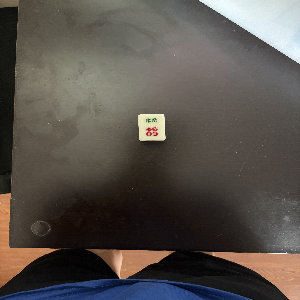

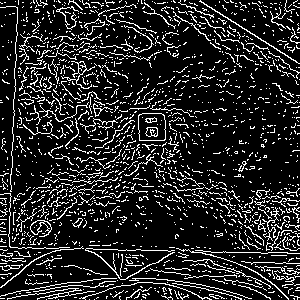

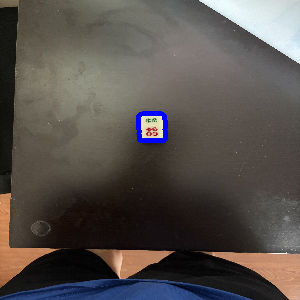

頂點數量: 4
area: 704.5
向右傾斜（左上抬高）
WL 25.019992006393608 0.0
fuck
更正：向左傾斜（右上抬高）
right_up_corner = left_up_corner
打橫兩個錯 --> y value 太接近


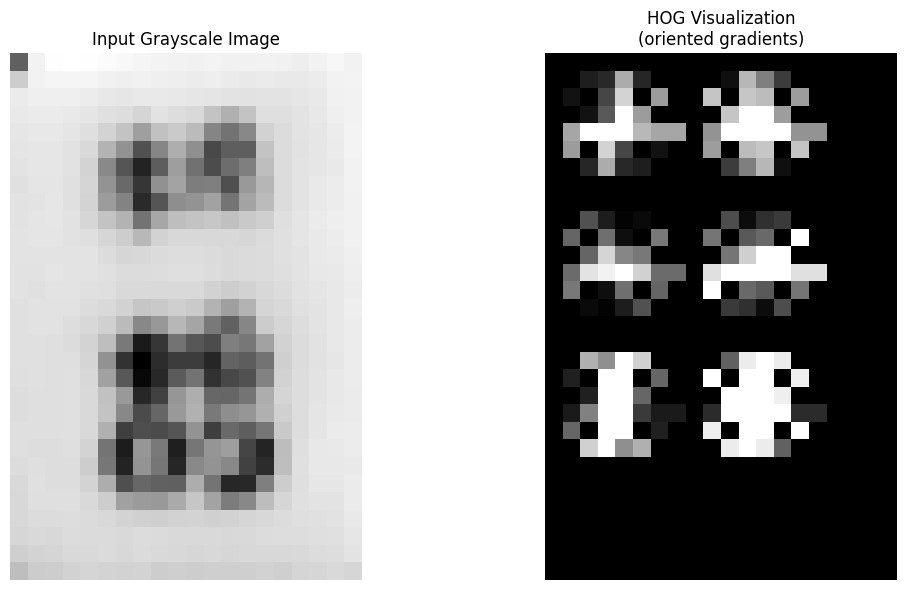

The MJ is :  ['6tung']


In [ ]:
new_data_name = "testing_small_6tung.jpg"
new_data = get_features(new_data_name)
new_data = np.array([new_data])
new_data_scaled = scaler.transform(new_data)
prediction = clf.predict(new_data_scaled)
print("The MJ is : ",prediction)

In [ ]:
# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. 定義相同路徑
save_path = '/content/drive/My Drive/small_tung_ji_model/'   # 跟上面一樣

import os
os.makedirs(save_path,exist_ok = True)

# 3. 載入模型和 scaler
import joblib
joblib.dump(clf,save_path + 'clf_model.joblib')
joblib.dump(scaler,save_path + 'scaler.joblib')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['/content/drive/My Drive/small_tung_ji_model/scaler.joblib']